# CPGRAMS Grievance Data Acquisition and Analysis
___

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import seaborn as sns

## Conversion of Json to Csv
___

Loads the entire JSON file into memory at once with `json.load()`.
Processes all data at once in memory.
Faster for small to medium files but memory-intensive for large files.

In [ ]:
# https://www.kaggle.com/datasets/ayushyajnik/government-of-india-grievance-report?utm_source=chatgpt.com&select=no_pii_action_history.json

In [ ]:
import json

# ---- Step 1: Read the JSON file ----
with open("No_PII_Grievance_Data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# ---- Step 2: Normalize Mongo Extended JSON ----
def normalize_value(val):
    """Convert MongoDB Extended JSON values into plain Python types"""
    if isinstance(val, dict):
        # Handle $date
        if "$date" in val:
            return val["$date"]
        # Handle $numberLong
        if "$numberLong" in val:
            return int(val["$numberLong"])
        # Fallback: recursively normalize
        return {k: normalize_value(v) for k, v in val.items()}
    elif isinstance(val, list):
        return [normalize_value(v) for v in val]
    else:
        return val

normalized_data = [ {k: normalize_value(v) for k, v in item.items()} for item in data ]

# ---- Step 3: Convert to DataFrame ----
df = pd.DataFrame(normalized_data)

# ---- Step 4: Save to CSV ----
df.to_csv("No_PII_Grievance_Data.csv", index=False, encoding="utf-8")

print("✅ Conversion done!")


&nbsp;

Uses `ijson` to stream the JSON objects one by one, which is more memory-efficient for large files.
Processes data incrementally as it's read from the file.
 Uses `ijson`, a specialized library for iterative JSON parsing.
  Potentially slower but handles very large files without memory issues.

In [8]:
# pip install ijson pandas

In [3]:
import ijson

input_file = "No_PII_Action_History_Data.json"
output_file = "No_PII_Action_History_Data.csv"

def normalize_value(val):
    """Convert MongoDB Extended JSON values into plain Python types"""
    if isinstance(val, dict):
        if "$date" in val:
            return val["$date"]
        if "$numberLong" in val:
            return int(val["$numberLong"])
        return {k: normalize_value(v) for k, v in val.items()}
    elif isinstance(val, list):
        return [normalize_value(v) for v in val]
    else:
        return val

# ---- Step 1: Stream JSON objects one by one ----
rows = []
with open(input_file, "r", encoding="utf-8") as f:
    objects = ijson.items(f, "item")   # iterate over each element in the JSON array
    for obj in objects:
        row = {k: normalize_value(v) for k, v in obj.items()}
        rows.append(row)

# ---- Step 2: Convert to DataFrame ----
df = pd.DataFrame(rows)

# ---- Step 3: Save to CSV ----
df.to_csv(output_file, index=False, encoding="utf-8")

print("✅ Done! Saved as", output_file)


✅ Done! Saved as No_PII_Action_History_Data.csv


&nbsp;

## Reading the csv and building Data Frame
_________

The CSV file is read and loaded into a pandas DataFrame. The '_id' column is set as the index of the DataFrame for easier record identification. Column names are renamed to be more descriptive and meaningful. The columns are reordered to create a more logical structure for better data visualization and analysis.

In [2]:
df = pd.read_csv('../data/No_PII_Grievance_Data.csv')

In [3]:
df.sample(5)

,_id,CategoryV7,DiaryDate,UserCode,closing_date,dist_name,org_code,pincode,recvd_date,registration_no,remarks_text,resolution_date,sex,state,subject_content_text,v7_target
5227,PMOPG/E/2023/0001499,NaN,2023-01-02T21:50:33.143+0000,NaN,2023-01-25T00:00:00.000+0000,Ghazipur,PMOPG,233306,2023-01-02T00:00:00.000+0000,PMOPG/E/2023/0001499,NaN,NaN,M,UP,माननीय प्रधानमंत्री जी \r\nमेरा प्रधानमंत्री क...,NaN
33045,PRSEC/E/2023/0000630,NaN,2023-01-06T15:46:25.460+0000,NaN,2023-01-09T00:00:00.000+0000,NaN,GNCTD,110091,2023-01-06T00:00:00.000+0000,PRSEC/E/2023/0000630,Grievance details is not mentioned. So grieva...,2023-01-09T00:00:00.000+0000,X,DH,EDUCATION,NaN
35116,DARPG/E/2023/0001082,NaN,2023-01-06T17:59:22.197+0000,586922.0,2023-02-13T00:00:00.000+0000,Mumbai (Suburban),DARPG,400072,2023-01-06T17:59:17.003+0000,DARPG/E/2023/0001082,"Sir, As PER THE PF NUMBER X-X-X-X-X PERTANIS ...",2023-02-10T00:00:00.000+0000,M,MH,सेवामे:- श्रीमानजी केन्द्रीय श्रममंत्री महोदय ...,NaN
171143,MOCAV/E/2023/0000424,NaN,2023-01-31T21:23:43.117+0000,749242.0,2023-02-03T00:00:00.000+0000,Jammu,MOCAV,180005,2023-01-31T00:00:00.000+0000,MOCAV/E/2023/0000424,Please provide the flight details.,2023-02-03T00:00:00.000+0000,m,JK,The STD at the time of booking on 21.01.2023 w...,NaN
40074,GOVGJ/E/2023/0000440,NaN,2023-01-07T13:09:44.117+0000,1718154.0,2023-02-13T00:00:00.000+0000,Ahmadabad,GOVGJ,387810,2023-01-07T13:09:43.897+0000,GOVGJ/E/2023/0000440,ગુજરાત નગરપાલિકા અધિનિયમ - ૧૯૬૩ની કલમ-૬૫(૨‌)મ...,2023-02-13T00:00:00.000+0000,M,GJ,હું નામે રાણા યોગેશભાઈ અમૃતલાલ આપ સાહેબશ્રીને ...,NaN


In [4]:
df.index

RangeIndex(start=0, stop=175784, step=1)

In [5]:
df.columns

Index(['_id', 'CategoryV7', 'DiaryDate', 'UserCode', 'closing_date',
       'dist_name', 'org_code', 'pincode', 'recvd_date', 'registration_no',
       'remarks_text', 'resolution_date', 'sex', 'state',
       'subject_content_text', 'v7_target'],
      dtype='object')

In [6]:
df = df.set_index('_id')
df = df.rename(columns={'DiaryDate' : 'diary_date', 'UserCode' : 'user_code', 'CategoryV7' : 'category_v7', 'subject_content_text' : 'grievance_text'})
df = df.reindex(columns=['registration_no', 'user_code', 'category_v7', 'org_code', 'v7_target', 'recvd_date', 'diary_date', 'closing_date', 'resolution_date', 'sex', 'dist_name', 'state', 'pincode', 'grievance_text', 'remarks_text'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175784 entries, MORLY/E/2023/0000001 to MODEF/E/2023/0000652
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   registration_no  175784 non-null  object 
 1   user_code        98097 non-null   float64
 2   category_v7      63622 non-null   float64
 3   org_code         175401 non-null  object 
 4   v7_target        56663 non-null   object 
 5   recvd_date       175784 non-null  object 
 6   diary_date       175784 non-null  object 
 7   closing_date     162365 non-null  object 
 8   resolution_date  106904 non-null  object 
 9   sex              175784 non-null  object 
 10  dist_name        122808 non-null  object 
 11  state            175521 non-null  object 
 12  pincode          161502 non-null  object 
 13  grievance_text   175781 non-null  object 
 14  remarks_text     106904 non-null  object 
dtypes: float64(2), object(13)
memory usage: 21.5+ MB


In [8]:
df.sample(5)

,registration_no,user_code,category_v7,org_code,v7_target,recvd_date,diary_date,closing_date,resolution_date,sex,dist_name,state,pincode,grievance_text,remarks_text
_id,,,,,,,,,,,,,,,
PMOPG/D/2023/0019681,PMOPG/D/2023/0019681,NaN,NaN,PMOPG,NaN,2023-01-24T00:00:00.000+0000,2023-01-31T09:59:02.560+0000,2023-07-12T00:00:00.000+0000,2023-07-10T00:00:00.000+0000,M,Valsad,GJ,396001,PG/RA,"અરજદારશ્રી શરદ એસ. કાપડીયા, રહે. આંગન એપાર્ટમ..."
MORTH/E/2023/0001252,MORTH/E/2023/0001252,164637.0,638.0,MORTH,No,2023-01-24T13:38:48.767+0000,2023-01-24T13:38:48.767+0000,2023-03-13T00:00:00.000+0000,2023-03-13T00:00:00.000+0000,M,Uttara Kannada,KN,581320,Road Transport and Highways >> Construction & ...,Reply copy attached.
MORLY/E/2023/0002313,MORLY/E/2023/0002313,1732406.0,11561.0,MORLY,No,2023-01-26T14:37:48.340+0000,2023-01-26T14:37:48.340+0000,2023-02-07T00:00:00.000+0000,2023-02-07T00:00:00.000+0000,M,Etawah,UP,NaN,"Railways, ( Railway Board) >> Construction /Re...",Supporting documents have been attached for k...
PMOPG/D/2023/0012068,PMOPG/D/2023/0012068,NaN,NaN,PMOPG,NaN,2023-01-07T00:00:00.000+0000,2023-01-17T13:22:57.403+0000,2023-01-17T00:00:00.000+0000,NaN,M,NaN,PC,609602,PG/SN,NaN
MORLY/E/2023/0001018,MORLY/E/2023/0001018,679237.0,11578.0,MORLY,No,2023-01-13T10:57:04.810+0000,2023-01-13T10:57:04.810+0000,2023-02-07T00:00:00.000+0000,2023-02-01T00:00:00.000+0000,M,Srikakulam,AP,532222,"Railways, ( Railway Board) >> Miscellaneous\r\...",This is a policy decision related to operatio...


&nbsp;

## Attribute Description of Grievance Records
________

| Attribute Name       | Description                                                      |
|-----------------------|------------------------------------------------------------------|
| _id                  | Grievance registration number                                    |
| registration_no      | Registration number of grievance                                 |
| user_code            | User’s unique code                                               |
| category_v7          | Category code for the grievance                                  |
| org_code             | Organisation code                                                |
| v7_target            | Yes/No, whether CategoryV7 maps to a target organisation         |
| recvd_date           | Date the grievance is received                                   |
| diary_date           | Date when grievance processing starts                            |
| closing_date         | Date when grievance is closed                                    |
| resolution_date      | Resolution date of the grievance                                 |
| sex                  | Gender of the complainant                                        |
| dist_name            | District name of the complainant                                 |
| state                | State of complainant registration                                |
| pincode              | Pincode of complainant’s address                                 |
| grievance_text | Grievance text (description of grievance)                        |
| remarks_text         | Remarks text provided by the organisation                        |


&nbsp;

## Data Cleaning 
____

* Standardize Categorical data
* Fix datatypes
* Handle duplicates
* Missing Values

###  Standardize categorical data

In [9]:
df['sex'].unique()

array(['M', 'F', 'm', 'O', 'f', 'X', 't', 'T'], dtype=object)

In [10]:
# Create a mapping dictionary for standardizing sex values
sex_mapping = {
    'M': 'Male',
    'm': 'Male',
    'F': 'Female',
    'f': 'Female',
    'O': 'Other',
    'X': 'Other',
    't': 'Other',
    'T': 'Other'
}

# Apply the mapping to standardize the sex column
df['sex'] = df['sex'].map(sex_mapping)

In [11]:
df['sex'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [12]:
print(df['state'].unique())
print(len(df['state'].unique()))

['WB' 'UP' 'TG' 'MH' 'JK' 'TN' 'OR' 'AP' 'RJ' 'JH' 'AS' 'MP' 'KN' 'CG'
 'HY' 'BH' 'PB' 'KL' 'UC' 'GJ' 'DH' 'TR' 'GD' 'HP' 'PC' 'XY' 'MZ' 'MG'
 'DN' 'XX' 'CH' 'MN' 'LK' '  ' 'AR' 'AN' nan 'DD' 'SK' 'NL' 'LD']
41


In [13]:
fix_map = {
    "TG": "TS",   # Telangana
    "KN": "KA",   # Karnataka
    "HY": "HR",   # Haryana
    "BH": "BR",   # Bihar
    "UC": "UK",   # Uttarakhand (old Uttaranchal code)
    "OR": "OD",   # Odisha (Orissa)
    "DH": "DN",   # Dadra & Nagar Haveli and Daman & Diu merged
    "DD": "DN",   # same as above
    "LK": "LA",   # Ladakh
    "PC": None,   # Invalid -> set to NaN
    "GD": None,   # Invalid -> set to NaN
    "XY": None,   # Invalid -> set to NaN
    "XX": None,   # Invalid -> set to NaN
    "  ": None    # Blank -> set to NaN
}

df['state'] = df['state'].replace(fix_map)

In [14]:
print(df['state'].unique())
print(len(df['state'].unique()))

['WB' 'UP' 'TS' 'MH' 'JK' 'TN' 'OD' 'AP' 'RJ' 'JH' 'AS' 'MP' 'KA' 'CG'
 'HR' 'BR' 'PB' 'KL' 'UK' 'GJ' 'DN' 'TR' None 'HP' 'MZ' 'MG' 'CH' 'MN'
 'LA' 'AR' 'AN' nan 'SK' 'NL' 'LD']
35


&nbsp;

### Fix data types

In [15]:
df['recvd_date'] = pd.to_datetime(df['recvd_date'], errors='coerce')
df['diary_date'] = pd.to_datetime(df['diary_date'], errors='coerce')
df['closing_date'] = pd.to_datetime(df['closing_date'], errors='coerce')
df['resolution_date'] = pd.to_datetime(df['resolution_date'], errors='coerce')

df['user_code'] = pd.to_numeric(df['user_code'], errors='coerce')
df['category_v7'] = pd.to_numeric(df['category_v7'], errors='coerce')
df['pincode'] = pd.to_numeric(df['pincode'], errors='coerce')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175784 entries, MORLY/E/2023/0000001 to MODEF/E/2023/0000652
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   registration_no  175784 non-null  object             
 1   user_code        98097 non-null   float64            
 2   category_v7      63622 non-null   float64            
 3   org_code         175401 non-null  object             
 4   v7_target        56663 non-null   object             
 5   recvd_date       175784 non-null  datetime64[ns, UTC]
 6   diary_date       175784 non-null  datetime64[ns, UTC]
 7   closing_date     162365 non-null  datetime64[ns, UTC]
 8   resolution_date  106904 non-null  datetime64[ns, UTC]
 9   sex              175784 non-null  object             
 10  dist_name        122808 non-null  object             
 11  state            172689 non-null  object             
 12  pincode          146678 non-nu

&nbsp;

### Handle Duplicates

In [17]:
df.duplicated().sum()
# no duplicates

0

### Missing Values

In [18]:
# Count missing values in each column
miss_vals = df.isnull().sum()

# Create a DataFrame with missing values statistics
missing_df = pd.DataFrame({
    'Missing Values': miss_vals.values,
    'Percentage (%)': (miss_vals / len(df) * 100).round(2)
})

# Sort by number of missing values (descending)
missing_df = missing_df.sort_values('Missing Values', ascending=False)

# Display the DataFrame
print("Missing Values Summary:")
display(missing_df)

# Optional: Filter to show only columns with missing values
# missing_df = missing_df[missing_df['Missing Values'] > 0]

Missing Values Summary:


,Missing Values,Percentage (%)
v7_target,119121,67.77
category_v7,112162,63.81
user_code,77687,44.19
resolution_date,68880,39.18
remarks_text,68880,39.18
dist_name,52976,30.14
pincode,29106,16.56
closing_date,13419,7.63
state,3095,1.76
org_code,383,0.22


In [19]:
# Drop specified columns
columns_to_drop = ['category_v7', 'registration_no', 'user_code', 'v7_target',
                    'diary_date', 'resolution_date', 
                    'dist_name', 'pincode']

df = df.drop(columns=columns_to_drop)

# Check remaining columns
for col in df.columns:
    print(col)

org_code
recvd_date
closing_date
sex
state
grievance_text
remarks_text


In [20]:
# Replace null values with "No remarks provided"
df['remarks_text'] = df['remarks_text'].fillna("No remarks provided")

# Drop rows where closing_date, state, or org_code are null
df = df.dropna(subset=['closing_date', 'state', 'org_code', 'grievance_text'])


In [21]:
# Count missing values in each column
miss_vals = df.isnull().sum()

# Create a DataFrame with missing values statistics
missing_df = pd.DataFrame({
    'Missing Values': miss_vals.values,
    'Percentage (%)': (miss_vals / len(df) * 100).round(2)
})

# Sort by number of missing values (descending)
missing_df = missing_df.sort_values('Missing Values', ascending=False)

# Display the DataFrame
print("Missing Values Summary:")
display(missing_df)

# Optional: Filter to show only columns with missing values
# missing_df = missing_df[missing_df['Missing Values'] > 0]

Missing Values Summary:


,Missing Values,Percentage (%)
org_code,0,0.0
recvd_date,0,0.0
closing_date,0,0.0
sex,0,0.0
state,0,0.0
grievance_text,0,0.0
remarks_text,0,0.0


&nbsp;

## Handling Anomalies in dataset
_______

In [22]:
### Remove rows where recv_date > closing_date

# Remove rows with invalid date relationships
df = df[df['recvd_date'] <= df['closing_date']]



In [25]:
df.shape

(156600, 7)

In [26]:
df.sample(7)

,org_code,recvd_date,closing_date,sex,state,grievance_text,remarks_text
_id,,,,,,,
DSEHE/E/2023/0000716,DSEHE,2023-01-28 09:14:37.517000+00:00,2023-02-01 00:00:00+00:00,Male,UP,Higher Education >> Miscelleneous/Others Griev...,"Dear Sir, \r\nThe specification of the equipme..."
MINHA/E/2023/0001466,MINHA,2023-01-17 17:39:03.267000+00:00,2023-04-05 00:00:00+00:00,Male,GJ,Home Affairs >> Matter Related to Unethical pr...,અરજદારશ્રીની અરજી સબંધે કરેલ કાર્યવાહીનો અહેવ...
PRSEC/E/2023/00114,GOVBH,2023-01-02 00:00:00+00:00,2023-04-26 00:00:00+00:00,Other,BR,To\r\nThe honble chairman\r\nTelecom regulator...,No remarks provided
MORLY/E/2023/0002690,MORLY,2023-01-31 16:30:26.540000+00:00,2023-02-01 00:00:00+00:00,Male,BR,"Railways, ( Railway Board) >> Service matter\r...",Reply attached\r\n
DEABD/E/2023/0004085,DEABD,2023-01-12 17:07:20.540000+00:00,2023-02-14 00:00:00+00:00,Female,MP,Financial Services (Banking Division) >> Defic...,Our concerned department confirmed that Rs 90...
PMOPG/E/2023/0014264,PMOPG,2023-01-16 00:00:00+00:00,2023-01-23 00:00:00+00:00,Male,MP,"सेवा में,\r\n श्रीमान जी प्रधानमंत्री कार्य...",The grievance made by the complainant is suit...
DOAAC/E/2023/0002530,DOAAC,2023-01-12 19:18:52.947000+00:00,2023-03-25 00:00:00+00:00,Male,RJ,Agriculture and Farmers Welfare >> Crop Insura...,No remarks provided


In [27]:
df.to_csv('../data/grievance_dataset.csv', index = True)

&nbsp;

## Exploratory Data Analysis
___

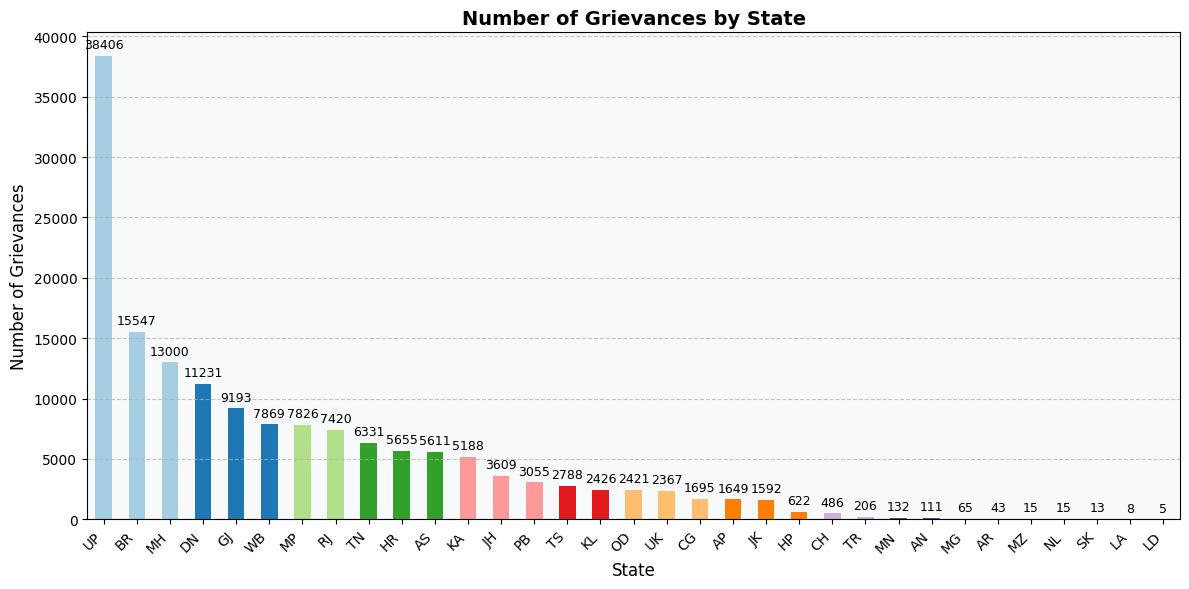

In [28]:
plt.figure(figsize=(12, 6))  # Larger figure for better readability

# Get state counts and sort them in descending order
state_counts = df['state'].value_counts()

# Create a bar plot with a more appealing color palette
ax = state_counts.plot(kind='bar', color=plt.cm.Paired(np.linspace(0, 1, len(state_counts))))

# Enhance the title and add labels
plt.title("Number of Grievances by State", fontsize=14, fontweight='bold')
plt.xlabel("State", fontsize=12)
plt.ylabel("Number of Grievances", fontsize=12)

# Add data labels on top of each bar
for i, count in enumerate(state_counts):
    plt.text(i, count + (state_counts.max() * 0.01), f'{count}', 
             ha='center', va='bottom', fontsize=9)

# Improve tick labels
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a light background color to distinguish the plot area
ax.set_facecolor('#f8f9fa')

plt.tight_layout()

C:\Users\kinge\AppData\Local\Temp\ipykernel_13200\3179244838.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x='sex', data=df, palette=colors)
C:\Users\kinge\AppData\Local\Temp\ipykernel_13200\3179244838.py:10: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax1 = sns.countplot(x='sex', data=df, palette=colors)


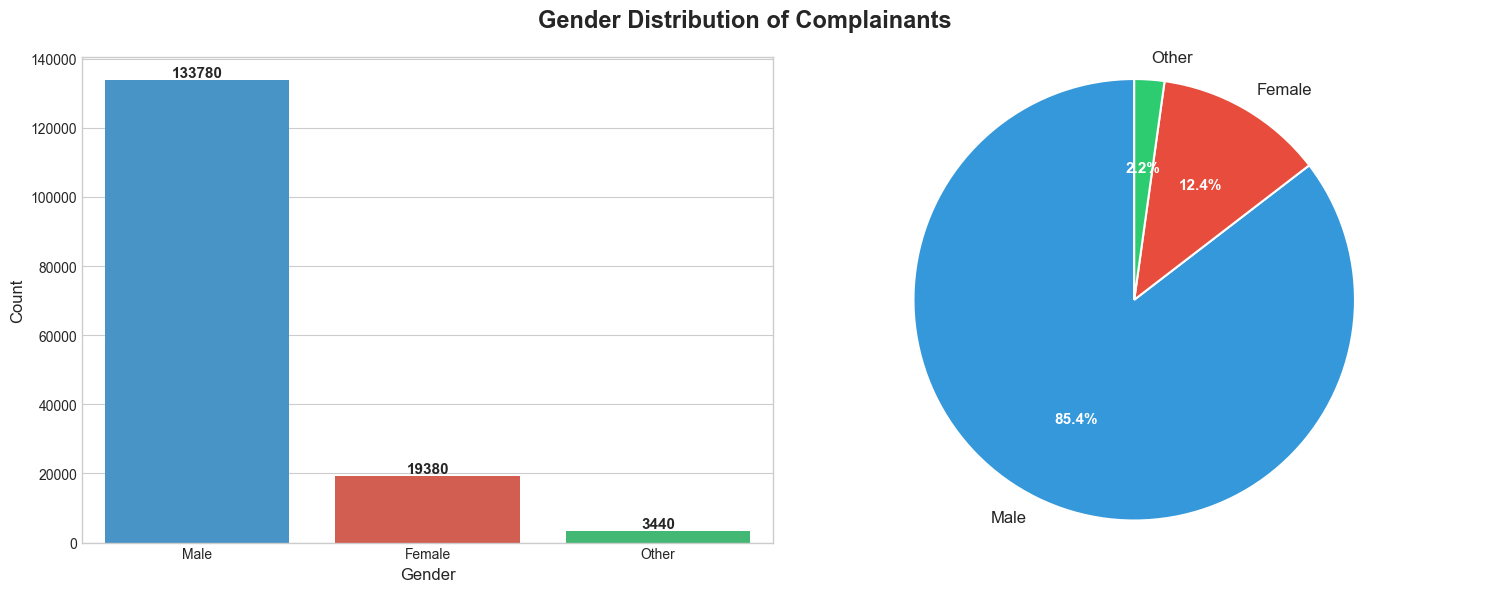

In [29]:
# Set a more professional style
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 6))

# Create a custom color palette
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']  # Blue, Red, Green, Orange

# Subplot 1: Enhanced count plot
plt.subplot(1, 2, 1)
ax1 = sns.countplot(x='sex', data=df, palette=colors)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add count labels on top of bars
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 2: Enhanced pie chart
plt.subplot(1, 2, 2)
gender_counts = df['sex'].value_counts()
wedges, texts, autotexts = plt.pie(gender_counts, 
                                   labels=gender_counts.index, 
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors[:len(gender_counts)],
                                   wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
                                   textprops={'fontsize': 12})

# Enhance pie chart text
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

plt.axis('equal')
plt.suptitle("Gender Distribution of Complainants", fontsize=17, fontweight='bold')

plt.tight_layout()

Number of unique values in 'org_code': 192


C:\Users\kinge\AppData\Local\Temp\ipykernel_13200\3697938747.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_counts.index, y=top_10_counts.values, palette='viridis')


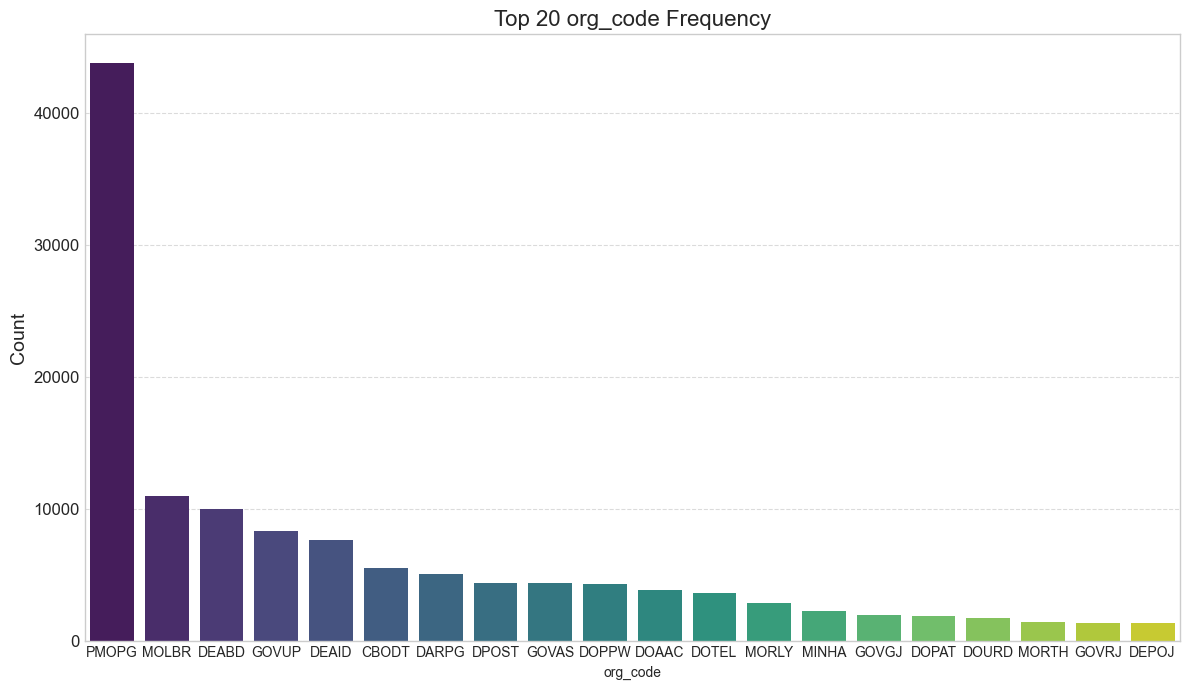

,Frequency,Percentage (%)
org_code,,
PMOPG,43776,27.954023
MOLBR,11009,7.030013
DEABD,10012,6.393359
GOVUP,8377,5.349298
DEAID,7689,4.909962
CBODT,5555,3.547254
DARPG,5082,3.245211
DPOST,4455,2.844828
GOVAS,4445,2.838442


In [39]:
column_name = 'org_code'

# Get the number of unique values
unique_count = df[column_name].nunique()
print(f"Number of unique values in '{column_name}': {unique_count}")

# Method 2: Get the actual unique values and their count
unique_values = df[column_name].unique()
# print(f"\nUnique values in '{column_name}' ({len(unique_values)} total):")
# print(unique_values)

# Method 3: Get value counts (frequency of each unique value)
value_counts = df[column_name].value_counts()
# print("\nValue counts (frequency of each unique value):")
# print(value_counts)

# Method 4: Get value counts as percentages
value_percentages = df[column_name].value_counts(normalize=True) * 100
# print("\nValue percentages:")
# print(value_percentages)

# Calculate Frequency
frequency = df[column_name].value_counts()

# Calculate Percentage
percentage = df[column_name].value_counts(normalize=True) * 100

# Combine into a single DataFrame
summary_table = pd.DataFrame({
    'Frequency': frequency,
    'Percentage (%)': percentage
})

# Optional: Round the percentage to 2 decimal places for cleaner output
summary_table['Percentage (%)'] = summary_table['Percentage (%)'].round(6)

# Calculate value counts and take the top 10
top_10_counts = df[column_name].value_counts().head(20)

# Plot
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_counts.index, y=top_10_counts.values, palette='viridis')
plt.title(f'Top 20 {column_name} Frequency', fontsize=16)
plt.ylabel('Count', fontsize=14)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display the table
summary_table.head(20)

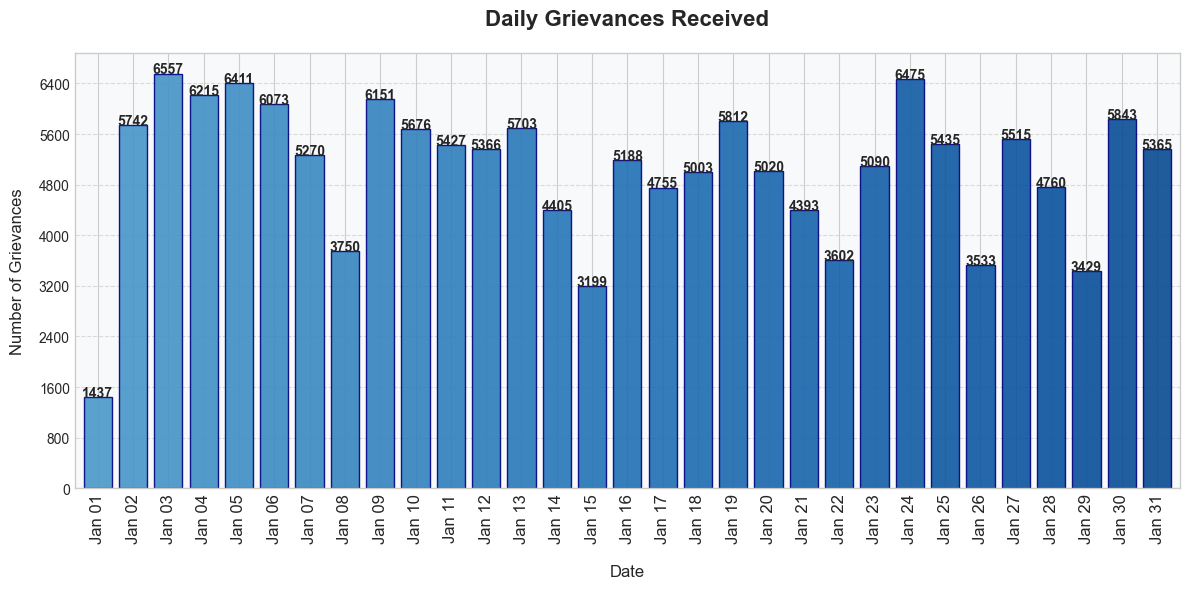

In [30]:
# First convert timezone-aware datetimes to timezone-naive by normalizing to a specific timezone
# Then get daily counts and ensure they're sorted by date
daily_counts = df['recvd_date'].dt.tz_localize(None).dt.to_period('D').value_counts().sort_index()

# Convert period index to datetime for better plotting
daily_counts.index = pd.to_datetime(daily_counts.index.astype(str))

# Create figure with appropriate size
plt.figure(figsize=(12, 6))

# Plot the data
ax = plt.gca()

# Bar plot with enhanced color - using a more vibrant blue with gradient
colors = plt.cm.Blues(np.linspace(0.6, 0.9, len(daily_counts)))
bars = daily_counts.plot(
    kind='bar',
    color=colors,
    width=0.8,
    ax=ax,
    edgecolor='navy',  # Adding edge color for better definition
    alpha=0.9
)

# Enhance the grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# For fewer data points, format each date
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(fontsize=12, rotation=90)

# Ensure y-axis starts at 0 and uses integers
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Add labels and title with better formatting
plt.title("Daily Grievances Received", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Date", fontsize=12, labelpad=15)
plt.ylabel("Number of Grievances", fontsize=12, labelpad=10)

# Add frequency labels on top of each bar
for i, v in enumerate(daily_counts):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=10)

# Add a subtle background color to enhance readability
ax.set_facecolor('#f8f9fa')

plt.tight_layout()

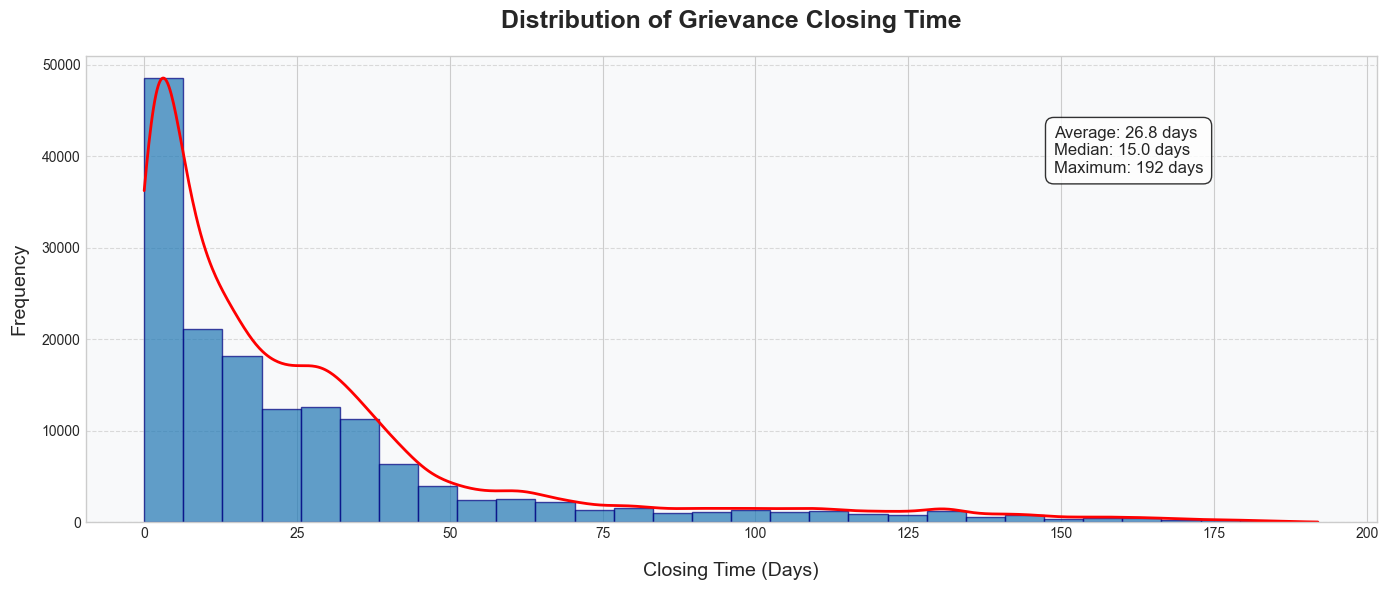

In [32]:
# Create figure with appropriate size
plt.figure(figsize=(14, 6))

# Plot the distribution of closing time
ax = plt.gca()

# Calculate closing time in days
closing_time_days = (df['closing_date'] - df['recvd_date']).dt.days

# Replace any infinite values with NaN and drop them
closing_time_days = closing_time_days.replace([np.inf, -np.inf], np.nan).dropna()

# Create histogram using matplotlib instead of seaborn
n, bins, patches = ax.hist(closing_time_days, bins=30, color='#1f77b4', 
                          edgecolor='navy', alpha=0.7)

# Add KDE curve manually if needed
if len(closing_time_days) > 1:  # Need at least 2 points for KDE
    from scipy import stats
    density = stats.gaussian_kde(closing_time_days)
    x_vals = np.linspace(min(closing_time_days), max(closing_time_days), 1000)
    y_vals = density(x_vals)
    # Scale the KDE to match histogram height
    y_vals = y_vals * (max(n) / max(y_vals)) if max(y_vals) > 0 else y_vals
    ax.plot(x_vals, y_vals, 'r-', linewidth=2)

# Enhance the grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ensure x-axis uses integers
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Add labels and title with better formatting
plt.title("Distribution of Grievance Closing Time", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Closing Time (Days)", fontsize=14, labelpad=15)
plt.ylabel("Frequency", fontsize=14, labelpad=10)

# Add statistics as text
avg_days = closing_time_days.mean()
median_days = closing_time_days.median()
max_days = closing_time_days.max()

stats_text = (f"Average: {avg_days:.1f} days\n"
              f"Median: {median_days:.1f} days\n"
              f"Maximum: {max_days:.0f} days")

# Add text box with statistics
plt.text(0.75, 0.85, stats_text, transform=ax.transAxes,
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
         fontsize=12, verticalalignment='top')

# Add a subtle background color to enhance readability
ax.set_facecolor('#f8f9fa')

plt.tight_layout()

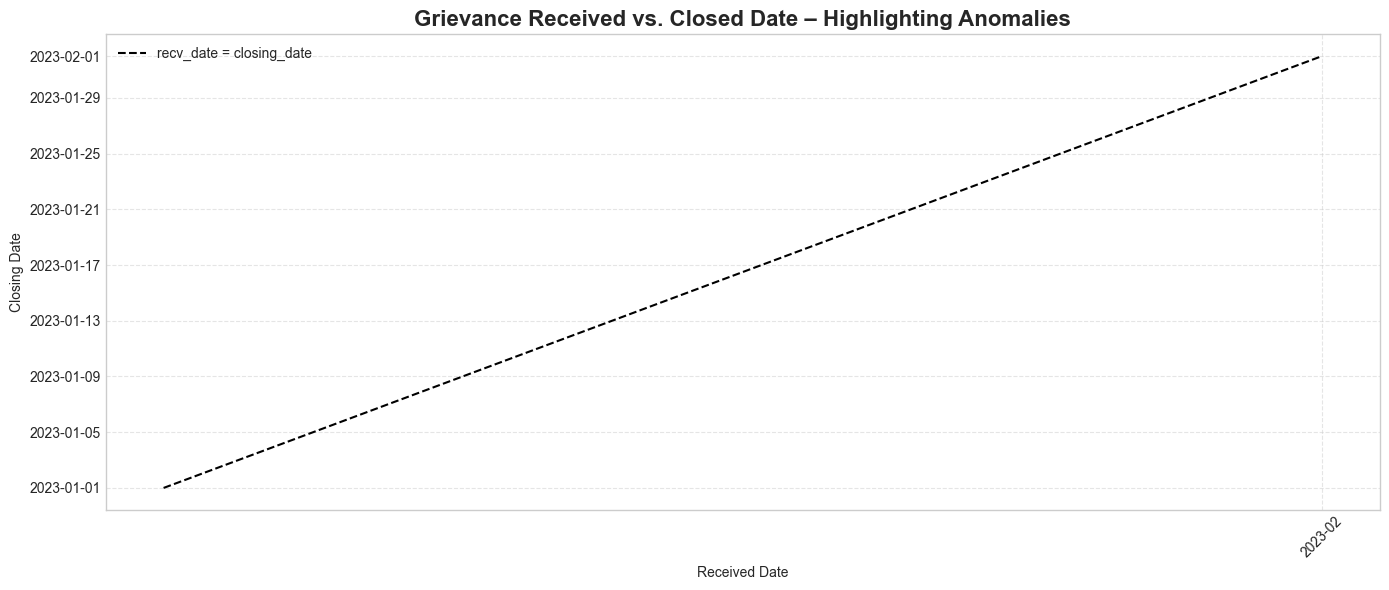

In [37]:
# Define the anomaly mask
anomaly_mask = df['closing_date'] < df['recvd_date']

plt.figure(figsize=(14, 6))

# Plot anomalies in bold red
sns.scatterplot(
    x='recvd_date', y='closing_date',
    data=df[anomaly_mask],
    color='red',
    label='Anomaly (close_date < recv_date)',
    marker='X',
    s=120
)

# Plot diagonal reference line
plt.plot([df['recvd_date'].min(), df['recvd_date'].max()],
         [df['recvd_date'].min(), df['recvd_date'].max()],
         color='black', linestyle='--',
         label='recv_date = closing_date')

# Improve date axis formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xlabel('Received Date')
plt.ylabel('Closing Date')
plt.title('Grievance Received vs. Closed Date – Highlighting Anomalies', fontsize = 16, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()